Define the default font sizes to make the figures prettier:

In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter, jaxfixedpt
from scipy import signal
import jax
import jax.numpy as jnp
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [2]:
from pathlib import Path
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Optional, Union, Tuple, Dict, Any
_Array = Union[jnp.ndarray]

IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

### 3.6.3 Channel Equalization Simulations
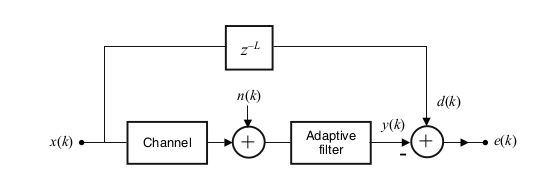

For communications perspective, the channel equalization or inverse filtering consists of estimating a transfer function to compensatefor the linear distortion caused by the channel. From another point of view, the objective is to force a prescribed dynamic behavior for the cascade of the channel (unknown system) and the adaptive filter, determined by the input signal.

In the ideal situation, where $n(k) = 0$ and the equalizer has sufficient order, the error signal is zero if both the transfer function channel $H(z)$ and adative filter $W(z)$ are inverse of each other within a possible delay $z^{-L}$ for $\delta[n-L]$ in time domain, that is :
$$W (z)H (z) = z^{−L} \quad \text{or} \quad W (z) = \frac{z^{−L}}{H (z)} $$

Example 3.7 Perform the equalization of a channel with the following impulse response: 
$$h(k) = 0.1 (0.5^k)$$

for $k = 0, 1, \ldots, 8$. Use a known training signal that consists of independent binary samples $(-1, 1)$. An additional Gaussian white noise with variance $10^{-2.5}$ is present at the channel output.

(a) Find the impulse response of an equalizer with $50$ coefficients.

(b) Convolve the equalizer impulse response at a given iteration after convergence, with the channel impulse response and comment on the result.

(a) We apply the LMS algorithm to solve the equalization problem and  measure the result to get the $\mu_{\max}$, the values of $\lambda_{\max} = 0.04275$ and $\sigma_x^2 = 0.01650$. Then apply stability condition 
$$
0 < \mu < \frac{1}{2\lambda_{\max} + \sum_{j=0}^N \lambda_j} < \frac{1}{\sum_{j=0}^N \lambda_j} = \frac{1}{\text{tr}[\mathbf{R}]}
$$
The resulting value of $\mu_{\max} = 1/\text{tr}[R] = 1.0985$ and we use $\mu = \mu_{\max} / 5 = 0.2197$ for the value of convergence factor.

In [6]:
import jax
import jax.numpy as jnp
from flax import linen as nn

class LMSChannelEqualizer(nn.Module):
    """Real LMS channel equalizer (matches your NumPy code)."""
    mu: float          # step size
    n_taps: int        # equalizer order N (number of coefficients)
    delay: int         # channel_order - 1, same as your code

    def setup(self):
        # Equalizer coefficients (real)
        self.w = self.variable(
            "state", "w",
            lambda: jnp.zeros((self.n_taps,), dtype=jnp.float32)
        )

    @nn.compact
    def __call__(self, r, d_train, n_iter: int, train: bool = True):
        """
        Args:
          r: channel_output_noisy, shape [L_r]
          d_train: training sequence, shape [L_d]
          n_iter: number of LMS iterations
        Returns:
          y_hist: equalizer output, shape [n_iter]
          e_hist: error sequence, shape [n_iter]
          w_hist: coefficient history, shape [n_iter, n_taps]
        """
        w0 = self.w.value

        def stepfn(w, k):
            # k is the iteration index (0..n_iter-1)
            start_idx = k + self.delay
            # x: last n_taps samples of r, reversed (just like NumPy)
            x = jax.lax.dynamic_slice(r, (start_idx,), (self.n_taps,))[::-1]

            # equalizer output
            y = jnp.dot(w, x)

            # desired symbol: training_signal[k + delay + delay]
            d_des = d_train[k + 2 * self.delay]

            e = d_des - y

            upd = 2.0 * self.mu * e * x
            w_new = jax.lax.cond(
                train,
                lambda _: w + upd,
                lambda _: w,
                operand=None,
            )
            return w_new, (y, e, w_new)

        ks = jnp.arange(n_iter, dtype=jnp.int32)
        w_final, (y_hist, e_hist, w_hist) = jax.lax.scan(stepfn, w0, ks)

        if train:
            self.w.value = w_final

        return y_hist, e_hist, w_hist


mu_max = 1.188354, using mu = 0.237671
Using delay = 8
Running 100000 LMS iterations


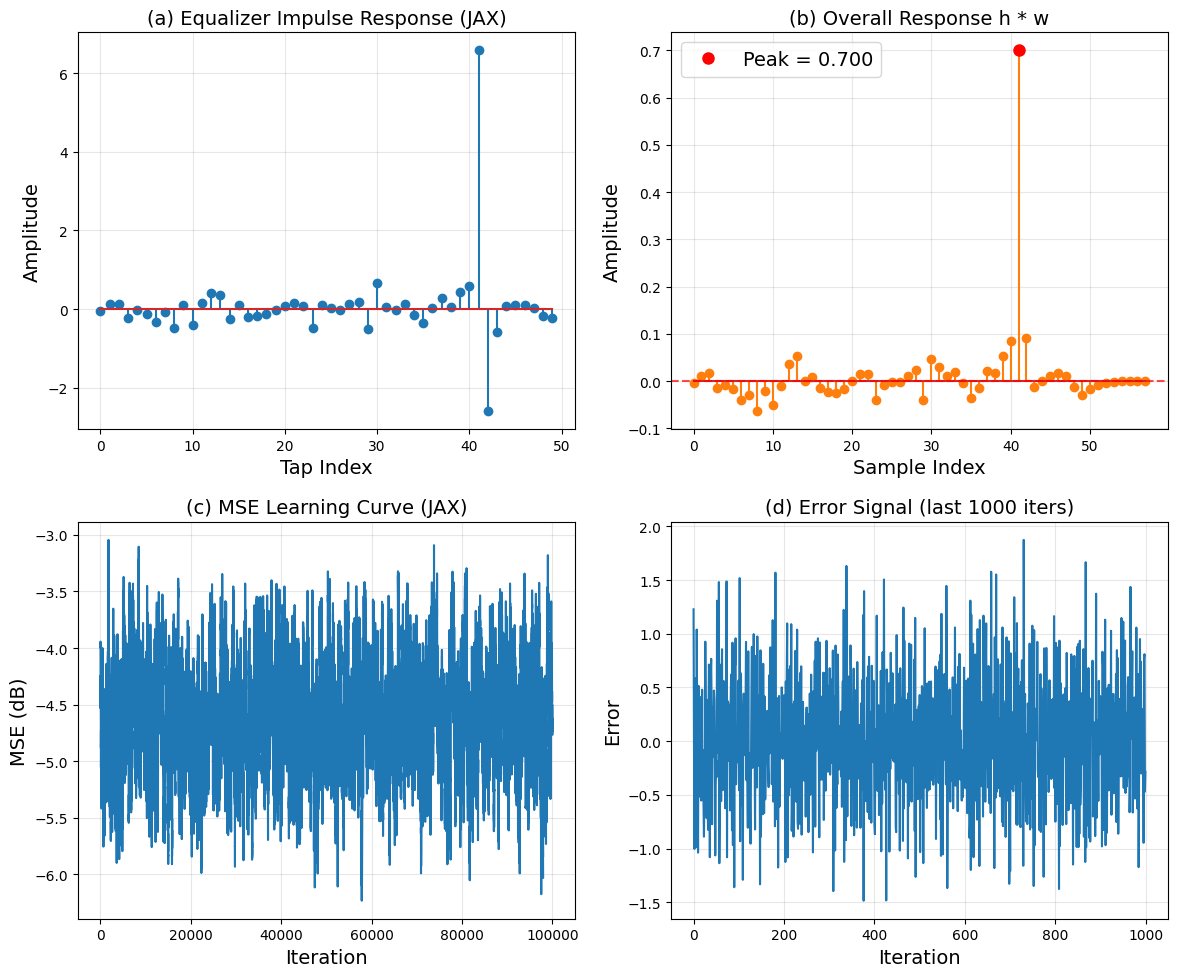

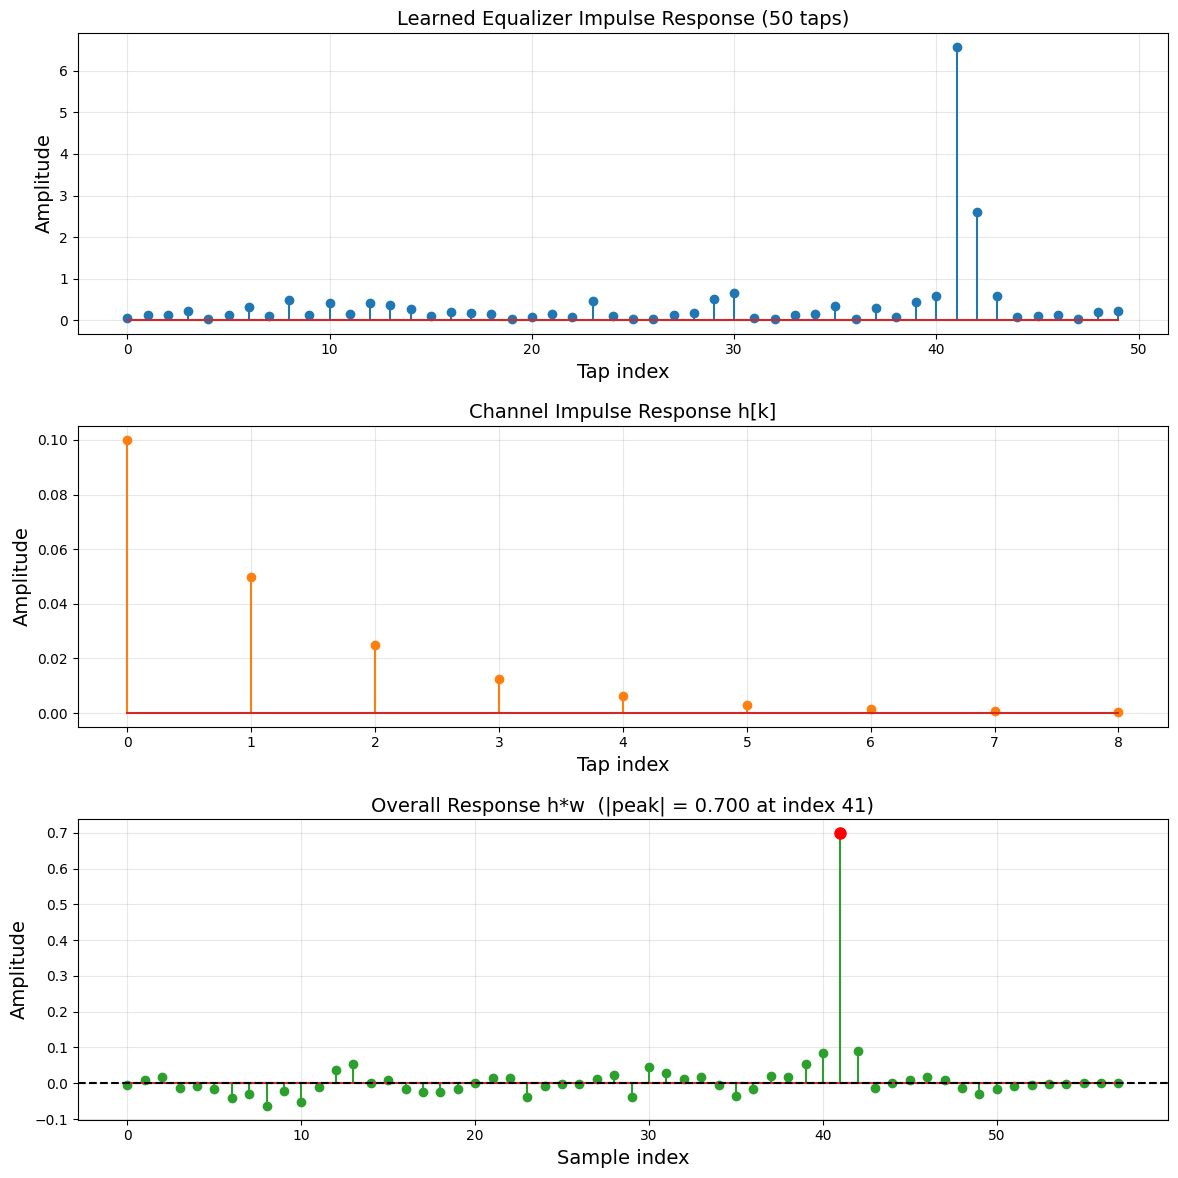

In [15]:
import matplotlib.pyplot as plt

def run_lms_equalizer_jax():
    # ----------------------------------------------------------
    # Parameters (same as your NumPy code)
    # ----------------------------------------------------------
    N = 50                       # equalizer order (taps)
    k_range = jnp.arange(0, 9)   # channel taps 0..8
    h = 0.1 * (0.5 ** k_range)
    channel_order = h.shape[0]

    n_iterations = 100_000
    noise_variance = 10 ** (-2.5)

    # Given values
    lambda_max = 0.04275
    sigma_x2 = 0.01650

    tr_R = (N + 1) * sigma_x2
    mu_max = 1.0 / tr_R
    mu = mu_max / 5.0

    print(f"mu_max = {mu_max:.6f}, using mu = {mu:.6f}")

    # ----------------------------------------------------------
    # Training signal and channel output
    # ----------------------------------------------------------
    key = jax.random.PRNGKey(0)

    training_length = n_iterations + N + channel_order
    key, subkey = jax.random.split(key)
    training_bits = jax.random.bernoulli(subkey, 0.5, (training_length,))
    training_signal = (2.0 * training_bits - 1.0).astype(jnp.float32)  # ±1

    # Channel output (full convolution)
    channel_output = jnp.convolve(training_signal, h, mode="full")

    key, subkey = jax.random.split(key)
    noise = jnp.sqrt(noise_variance) * jax.random.normal(
        subkey, channel_output.shape, dtype=jnp.float32
    )
    channel_output_noisy = channel_output + noise

    # ----------------------------------------------------------
    # LMS channel equalizer (Flax)
    # ----------------------------------------------------------
    delay = channel_order - 1
    print(f"Using delay = {delay}")

    # Compute max iterations that keep indices valid
    max_iter_r = int(channel_output_noisy.shape[0] - (delay + N))
    max_iter_d = int(training_signal.shape[0] - 2 * delay)
    n_iter = min(n_iterations, max_iter_r, max_iter_d)
    print(f"Running {n_iter} LMS iterations")

    eq = LMSChannelEqualizer(mu=mu, n_taps=N, delay=delay)

    # init and run
    variables = eq.init(
        key,
        channel_output_noisy.astype(jnp.float32),
        training_signal,
        n_iter,
    )

    (y_hist, e_hist, w_hist), variables = eq.apply(
        variables,
        channel_output_noisy.astype(jnp.float32),
        training_signal,
        n_iter,
        True,
        mutable=["state"],
    )

    w_final = w_hist[-1]

    # ----------------------------------------------------------
    # Overall response: channel ⊗ equalizer
    # ----------------------------------------------------------
    overall_response = jnp.convolve(h, w_final)

    # ----------------------------------------------------------
    # Plot (similar to your NumPy version)
    # ----------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # (a) equalizer impulse response
    axes[0, 0].stem(jnp.arange(N), w_final)
    axes[0, 0].set_title("(a) Equalizer Impulse Response (JAX)")
    axes[0, 0].set_xlabel("Tap Index")
    axes[0, 0].set_ylabel("Amplitude")
    axes[0, 0].grid(True, alpha=0.3)

    # (b) overall channel+equalizer response
    axes[0, 1].stem(jnp.arange(overall_response.shape[0]),
                    overall_response,
                    linefmt="C1-",
                    markerfmt="C1o")
    axes[0, 1].axhline(0, color="red", linestyle="--", alpha=0.7)
    axes[0, 1].set_title("(b) Overall Response h * w")
    axes[0, 1].set_xlabel("Sample Index")
    axes[0, 1].set_ylabel("Amplitude")
    axes[0, 1].grid(True, alpha=0.3)

    # mark main peak
    peak_idx = int(jnp.argmax(jnp.abs(overall_response)))
    peak_val = overall_response[peak_idx]
    axes[0, 1].plot(peak_idx, peak_val, "ro", markersize=8,
                    label=f"Peak = {float(peak_val):.3f}")
    axes[0, 1].legend()

    # (c) MSE learning curve (EMA like your code)
    mse_hist = jnp.zeros(n_iter)
    mse_hist = mse_hist.at[0].set(e_hist[0] ** 2)
    def ema(carry, e2):
        prev = carry
        new = 0.99 * prev + 0.01 * e2
        return new, new
    _, mse_hist = jax.lax.scan(ema, mse_hist[0], jnp.square(e_hist))
    axes[1, 0].plot(10 * jnp.log10(mse_hist + 1e-10))
    axes[1, 0].set_title("(c) MSE Learning Curve (JAX)")
    axes[1, 0].set_xlabel("Iteration")
    axes[1, 0].set_ylabel("MSE (dB)")
    axes[1, 0].grid(True, alpha=0.3)

    # (d) error signal (last 1000 iterations)
    last = min(1000, n_iter)
    axes[1, 1].plot(e_hist[-last:])
    axes[1, 1].set_title(f"(d) Error Signal (last {last} iters)")
    axes[1, 1].set_xlabel("Iteration")
    axes[1, 1].set_ylabel("Error")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return h, w_final, overall_response, mse_hist, e_hist

def plot_equalizer_coefficients(h, w_final, overall_response):
    import numpy as np
    import matplotlib.pyplot as plt

    # Convert possible JAX arrays to numpy
    h = np.asarray(h)
    w_final = np.asarray(w_final)
    overall_response = np.asarray(overall_response)

    N = len(w_final)
    K = len(h)

    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    # --------------------------------------------------------------
    # (1) Learned Equalizer Coefficients
    # --------------------------------------------------------------
    axes[0].stem(np.arange(N), np.abs(w_final))   # magnitude of taps
    axes[0].set_title("Learned Equalizer Impulse Response (50 taps)")
    axes[0].set_xlabel("Tap index")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    # --------------------------------------------------------------
    # (2) Channel Impulse Response h[k]
    # --------------------------------------------------------------
    axes[1].stem(np.arange(K), h, linefmt='C1-', markerfmt='C1o')
    axes[1].set_title("Channel Impulse Response h[k]")
    axes[1].set_xlabel("Tap index")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)

    # --------------------------------------------------------------
    # (3) Overall Response = h * w_final
    # --------------------------------------------------------------
    L = len(overall_response)
    axes[2].stem(np.arange(L), overall_response,
                 linefmt='C2-', markerfmt='C2o')
    axes[2].axhline(0, linestyle="--", color="black")

    # peak info
    peak_idx = int(np.argmax(np.abs(overall_response)))
    peak_val = overall_response[peak_idx]
    peak_mag = np.abs(peak_val)

    axes[2].plot(peak_idx, peak_val, "ro", markersize=8)

    axes[2].set_title(
        f"Overall Response h*w  (|peak| = {peak_mag:.3f} at index {peak_idx})"
    )
    axes[2].set_xlabel("Sample index")
    axes[2].set_ylabel("Amplitude")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


h, w_final, overall_resp, mse_hist, e_hist = run_lms_equalizer_jax()
plot_equalizer_coefficients(h, w_final, overall_resp)
